In [1]:
!date

Sat Sep 19 01:13:46 PDT 2026


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'

In [3]:
### every pool-level analysis so far (01f-01h) collapses 8 donors into one number, which throws
### away the fact that a pool's donors are not equally exposed -- only the ones with a close
### pool-mate are. scoring per DONOR instead turns 126 pools into ~1000 points on a single
### continuous axis: distance to that donor's nearest pool-mate. this is the relatedness gradient,
### assembled from pools already on disk rather than from new simulations.
x = pd.read_csv(f'{projdir}/csv/ambisim/droplet_scores_cov.csv', sep='\t')
m = np.load(f'{projdir}/csv/designs/1kg_chr22_dist_matrix.npz', allow_pickle=True)
D, sid = m['D'], list(m['sample_ids'])
pos = {s: i for i, s in enumerate(sid)}

In [4]:
x.head()

,pool,universe,strategy,rep,modality,barcode,is_true_singlet,called_singlet,correct,donor_correct,...,ll_gap,sng_gap,sng_dbl_gap,droplet_type,n_snps,n_reads_demux,true_reads,called_donor,true_donor,heldout
0,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACAACA,True,True,True,True,...,17.15,83.09,17.15,SNG,3232,3391,22915,HG02678,HG02678,False
1,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACATAG,True,True,True,True,...,10.20,106.56,10.20,SNG,4130,4488,30010,HG02816,HG02816,False
2,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCCTA,True,True,True,True,...,-0.23,47.29,-0.23,SNG,2582,2843,19977,NA19922,NA19922,False
3,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCTAT,True,True,True,True,...,-1.42,9.73,-1.42,SNG,718,741,5237,NA20274,NA20274,False
4,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCTTG,True,True,True,True,...,19.78,156.28,19.78,SNG,6682,7458,51490,HG03136,HG03136,False


In [5]:
x.shape

(2303744, 21)

In [6]:
c = x[(x['modality'] == 'gex') & x['is_true_singlet'] & x['called_singlet']].copy()
rows = []
for p, d in c.groupby('pool'):
    donors = [l.strip() for l in open(f'{projdir}/txt/donors/{p}.txt') if l.strip()]
    donors = [q for q in donors if q in pos]
    idx = [pos[q] for q in donors]
    sub = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(sub, np.inf)
    nn = dict(zip(donors, sub.min(axis=1)))
    g = d.groupby('true_donor').agg(n=('donor_correct', 'size'), acc=('donor_correct', 'mean'),
                                    sng_gap=('sng_gap', 'mean'), ll_gap=('ll_gap', 'mean'))
    for don, r in g.iterrows():
        if don in nn and r['n'] >= 200:
            rows.append(dict(pool=p, donor=don, strategy=d['strategy'].iloc[0],
                             universe=d['universe'].iloc[0], nn_dist=nn[don], n=int(r['n']),
                             err10k=(1 - r['acc']) * 10000, sng_gap=r['sng_gap']))
grad = pd.DataFrame(rows)
grad['kind'] = np.where(grad['strategy'].str.startswith('adversarial_family'),
                        'family pool', 'unrelated pool')
print(len(grad), 'donor-level points across', grad['pool'].nunique(), 'pools')

994 donor-level points across 126 pools


In [7]:
grad.head()

,pool,donor,strategy,universe,nn_dist,n,err10k,sng_gap,kind
0,AFR_only__adversarial_mindist__rep1,HG01912,adversarial_mindist,AFR_only,103.542259,819,12.210012,72.154420,unrelated pool
1,AFR_only__adversarial_mindist__rep1,HG03439,adversarial_mindist,AFR_only,101.173119,859,11.641444,72.775006,unrelated pool
2,AFR_only__adversarial_mindist__rep1,HG03461,adversarial_mindist,AFR_only,101.774261,809,0.000000,76.663708,unrelated pool
3,AFR_only__adversarial_mindist__rep1,HG03520,adversarial_mindist,AFR_only,100.000000,802,37.406484,74.083903,unrelated pool
4,AFR_only__adversarial_mindist__rep1,NA18924,adversarial_mindist,AFR_only,102.142059,868,0.000000,74.080806,unrelated pool


In [8]:
grad.shape

(994, 9)

In [9]:
### the gradient. the lowest bin is where the parent-offspring pairs live.
grad['bin'] = pd.cut(grad['nn_dist'], [0, 80, 90, 100, 105, 110, 115, 120, np.inf])
gtab = grad.groupby('bin', observed=True).agg(n_donors=('donor', 'size'), nn_dist=('nn_dist', 'mean'),
                                              sng_gap=('sng_gap', 'mean'),
                                              err10k=('err10k', 'mean')).reset_index()
print(gtab.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

           bin  n_donors  nn_dist  sng_gap  err10k
   (0.0, 80.0]        36    75.78    38.93   36.52
  (80.0, 90.0]        20    87.53    54.57   18.18
 (90.0, 100.0]       137    96.93    63.00   13.96
(100.0, 105.0]       260   102.78    69.05    9.47
(105.0, 110.0]       228   107.47    73.36    8.18
(110.0, 115.0]       179   112.44    75.14    8.02
(115.0, 120.0]        91   117.11    79.39    6.44
  (120.0, inf]        43   121.51    83.85    4.05


In [10]:
### the question this settles: are related donors a distinct failure mode, or just the bottom
### of the same curve? if the latter, a relatedness-gradient simulation would only interpolate
### between points we already have.
for k, d in grad.groupby('kind'):
    print(f'{k:16s} n={len(d):4d}  nn_dist {d["nn_dist"].min():.1f}-{d["nn_dist"].max():.1f}  '
          f'median err10k={d["err10k"].median():.2f}')
u = grad[grad['kind'] == 'unrelated pool']
print(f'\nunrelated donors only: nn_dist ~ err10k  rho={spearmanr(u["nn_dist"], u["err10k"])[0]:+.3f}')
print(f'unrelated donors only: nn_dist ~ sng_gap rho={spearmanr(u["nn_dist"], u["sng_gap"])[0]:+.3f}')

family pool      n=  48  nn_dist 74.2-109.4  median err10k=24.22
unrelated pool   n= 946  nn_dist 85.7-125.7  median err10k=11.20

unrelated donors only: nn_dist ~ err10k  rho=-0.209
unrelated donors only: nn_dist ~ sng_gap rho=+0.597


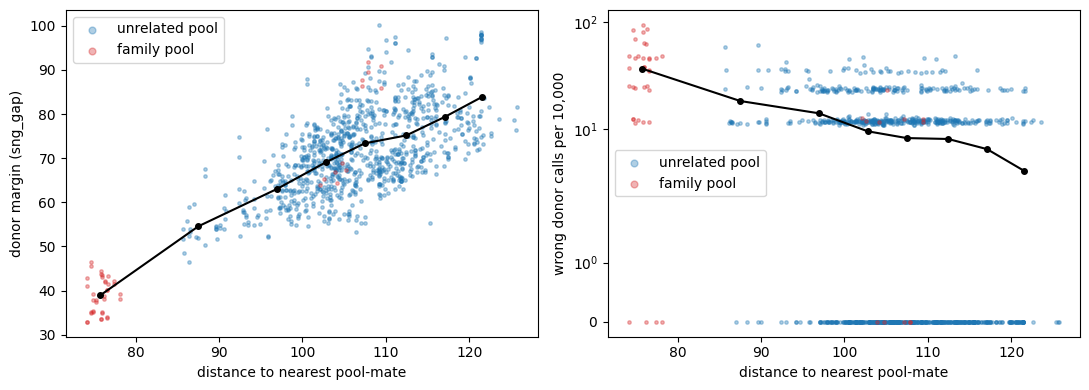

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for k, col in [('unrelated pool', 'C0'), ('family pool', 'C3')]:
    d = grad[grad['kind'] == k]
    axes[0].scatter(d['nn_dist'], d['sng_gap'], s=6, alpha=.35, c=col, label=k)
    axes[1].scatter(d['nn_dist'], d['err10k'], s=6, alpha=.35, c=col, label=k)
axes[0].plot(gtab['nn_dist'], gtab['sng_gap'], 'k-o', lw=1.5, ms=4)
axes[1].plot(gtab['nn_dist'], gtab['err10k'], 'k-o', lw=1.5, ms=4)
axes[0].set_ylabel('donor margin (sng_gap)')
axes[1].set_ylabel('wrong donor calls per 10,000'); axes[1].set_yscale('symlog')
for a in axes:
    a.set_xlabel('distance to nearest pool-mate'); a.legend(markerscale=2)
plt.tight_layout()
plt.show()

In [12]:
outdir = f'{projdir}/csv/ambisim'
grad.drop(columns='bin').to_csv(f'{outdir}/donor_nn_distance_gradient.csv', sep='\t', index=False)
gtab.assign(bin=gtab['bin'].astype(str)).to_csv(f'{outdir}/donor_nn_distance_binned.csv',
                                                sep='\t', index=False)

In [13]:
!date

Sat Sep 19 01:14:02 PDT 2026
